# Actividad Práctica: Análisis Demográfico con Datos Abiertos del MINSAL

Utilizaremos la base de datos de Egresos Hospitalarios del Departamento de Estadísticas e Información de Salud (DEIS) del Ministerio de Salud de Chile. El dataset contiene información sobre egresos hospitalarios en todo el país, incluyendo variables demográficas, clínicas y administrativas. El objetivo de este taller es trabajar con datos abiertos y aplicar técnicas de análisis exploratorio para comprender la información contenida en el dataset.

Al finalizar este taller, los y las estudiantes serán capaces de:
* Cargar y explorar bases de datos extensas utilizando pandas, identificando su estructura y calidad.
* Aplicar técnicas de filtrado, agrupación y transformación de datos para generar variables e indicadores.
* Calcular estadísticas descriptivas y proporciones a partir de variables categóricas y numéricas.
* Visualizar información mediante gráficos para facilitar la interpretación.
* Analizar relaciones entre variables demográficas y clínicas en un contexto de salud pública real.


##  1. Bases de datos abiertos: MINSAL
### 1.1. Introducción a los datos abiertos

Los datos abiertos son conjuntos de datos que están disponibles para el público de forma gratuita y sin restricciones. Estos datos pueden ser utilizados, modificados y compartidos por cualquier persona, lo que fomenta la transparencia, la innovación y la colaboración en diversas áreas, incluyendo la salud pública. En este taller, utilizaremos datos abiertos del Ministerio de Salud de Chile para realizar un análisis demográfico y clínico de los egresos hospitalarios en el país.

### 1.2. Egresos Hospitalarios

Los egresos hospitalarios son registros de pacientes que han sido dados de alta de un hospital después de recibir atención médica. Estos datos son fundamentales para comprender la carga de enfermedades, la utilización de servicios de salud y la calidad de la atención médica en un país. El Ministerio de Salud de Chile publica regularmente datos sobre egresos hospitalarios, que incluyen información demográfica, diagnósticos, procedimientos y otros aspectos relevantes.

Estos se encuentran disponibles en el sitio web del [Departamento de Estadísticas e Información de Salud](https://deis.minsal.cl/). En particular utilizaremos la base "Egresos Hospitalarios por Comuna de Residencia (disociados) Año 2024".

Para acceder a los datos, pueden navegar a la sección de "Datos Abiertos" en el sitio web del MINSAL y buscar la base de datos correspondiente. Una vez que encuentren la base de datos, se descargara en formato zip.


![](./data/base_egresos.png)




## 1.3 Carga de datos

Google Colab funciona en un ambiente de nube basado en linux, por lo que podemos utilizar de manera directa commandos de linux para descargar y descomprimir archivos. En este caso, utilizaremos el comando `!wget` para descargar el archivo zip y luego lo descomprimiremos utilizando el comando `!unzip`.

In [ ]:
!wget https://repositoriodeis.minsal.cl/DatosAbiertos/EGRESOS/EGRESOS_2024.zip
!unzip EGRESOS_2024.zip

--2025-10-18 17:03:08--  https://repositoriodeis.minsal.cl/DatosAbiertos/EGRESOS/EGRESOS_2024.zip
Resolving repositoriodeis.minsal.cl (repositoriodeis.minsal.cl)... 200.29.130.230
Connecting to repositoriodeis.minsal.cl (repositoriodeis.minsal.cl)|200.29.130.230|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8769182 (8.4M) [application/x-zip-compressed]
Saving to: ‘EGRESOS_2024.zip’

EGRESOS_2024.zip    100%[===================>]   8.36M  2.65MB/s    in 3.2s    

2025-10-18 17:03:13 (2.65 MB/s) - ‘EGRESOS_2024.zip’ saved [8769182/8769182]

Archive:  EGRESOS_2024.zip
  inflating: EGRESOS_2024.csv        
  inflating: Diccionario BD egresos hospitalario.xlsx  


Se recomienda descargar el dataset en su computador para visualizar el archivo `Diccionario BD egresos hospitalario.xlsx` y conocer la estructura de la base de datos.

Las variables que se encuentran en el diccionario son las siguientes:


<center>

| Nombre   Variable                | Descripción                                                                      |
|----------------------------------|----------------------------------------------------------------------------------|
| PERTENENCIA_ESTABLECIMIENTO_SALU | Tipo de pertenencia (Perteneciente o   No perteneciente al SNSS)                 |
| SEXO                             | Código del sexo   biologico del paciente                                         |
| GRUPO_EDAD                       | Grupo de edad del   paciente al momento de su ingreso                            |
| ETNIA                            | Se identifica o no   con una etnia                                               |
| GLOSA_PAIS_ORIGEN                | Indica si es chileno   o extranjero                                              |
| COMUNA_RESIDENCIA                | Código comuna de   residencia del paciente                                       |
| GLOSA_COMUNA_RESIDENCIA          | Nombre de la comuna   de residencia                                              |
| REGION_RESIDENCIA                | Código región de   residencia del paciente                                       |
| GLOSA_REGION_RESIDENCIA          | Nombre de la región   de residencia                                              |
| PREVISION                        | Código de previsión   de salud del paciente al momento del ingreso               |
| GLOSA_PREVISION                  | Glosa previsión de   salud del paciente al momento del ingreso                   |
| ANO_EGRESO                       | Año del egreso                                                                   |
| DIAG1                            | Código CIE-10 del   diagnostico principal                                        |
| DIAG2                            | Código CIE-10 de la   causa externa                                              |
| DIAS_ESTAD                       | Días de estada total                                                             |
| CONDICION_EGRESO                 | Código   de la condición al egreso del paciente          1=Vivo      2=Fallecido |

</center>


## 2. Trabajando con datos

### 2.1 Carga de librerías

Cargue las librerías necesarias que nos permitan leer archivos csv y visualizar resultados

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
# como accedemos a los datos cuando el archivo excel tiene multiples hojas
df_diccionario = pd.ExcelFile('Diccionario BD egresos hospitalario.xlsx')
df_diccionario.sheet_names

['Hoja1', 'codigo CIE-10']

In [ ]:
# Leemos la primera hoja de la tabla excel y vemos que corresponde al nombre de la variable y la descripción
df_variables = pd.read_excel('Diccionario BD egresos hospitalario.xlsx', sheet_name=df_diccionario.sheet_names[0])
df_variables

,Nombre Variable,Descripción
0,PERTENENCIA_ESTABLECIMIENTO_SALU,Tipo de pertenencia (Perteneciente o No perten...
1,SEXO,Código del sexo biologico del paciente
2,GRUPO_EDAD,Grupo de edad del paciente al momento de su in...
3,ETNIA,Se identifica o no con una etnia
4,GLOSA_PAIS_ORIGEN,Indica si es chileno o extranjero
5,COMUNA_RESIDENCIA,Código comuna de residencia del paciente
6,GLOSA_COMUNA_RESIDENCIA,Nombre de la comuna de residencia
7,REGION_RESIDENCIA,Código región de residencia del paciente
8,GLOSA_REGION_RESIDENCIA,Nombre de la región de residencia
9,PREVISION,Código de previsión de salud del paciente al m...


In [ ]:
# el siguiente código accede y limpia la segunda hoja de la tabla xlsx
df_codigos = pd.read_excel('Diccionario BD egresos hospitalario.xlsx', sheet_name=df_diccionario.sheet_names[1])
df_codigos.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Códigos CIE10 Diag1-Diag2,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CODIGO SUBCATEGORIA,GLOSA SUBCATEGORIA,CAPITULO,GLOSA CAPITULO,CODIGO GRUPO,GLOSA GRUPO,CODIGO CATEGORIA,GLOSA CATEGORIA
8,A000,"CÓLERA DEBIDO A VIBRIO CHOLERAE O1, BIOTIPO CH...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
9,A001,"CÓLERA DEBIDO A VIBRIO CHOLERAE 01, BIOTIPO EL...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera


In [ ]:
df_codigos_clean = df_codigos.copy()
df_codigos_clean = df_codigos_clean.drop(df_codigos_clean[df_codigos_clean['Unnamed: 0'].isnull()==True].index)
df_codigos_clean.reset_index(inplace=True, drop=True)
df_codigos_clean

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,CODIGO SUBCATEGORIA,GLOSA SUBCATEGORIA,CAPITULO,GLOSA CAPITULO,CODIGO GRUPO,GLOSA GRUPO,CODIGO CATEGORIA,GLOSA CATEGORIA
1,A000,"CÓLERA DEBIDO A VIBRIO CHOLERAE O1, BIOTIPO CH...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
2,A001,"CÓLERA DEBIDO A VIBRIO CHOLERAE 01, BIOTIPO EL...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
3,A009,"CÓLERA, NO ESPECIFICADO",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
4,A010,FIEBRE TIFOIDEA,A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A01,Fiebres tifoidea y paratifoidea
...,...,...,...,...,...,...,...,...
12592,U88X,AGENTE BACTERIANO RESISTENTE A MULTIPLES ANTIB...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12593,U898,AGENTE BACTERIANO RESISTENTE A OTRO ANTIBIOTIC...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12594,U899,AGENTE BACTERIANO RESISTENTE A ANTIBIOTICO NO...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12595,U071,"COVID-19, virus identificado",U00-U99,Códigos para propósitos especiales,U00-U49,Asignación provisoria de nuevas afecciones de ...,U07,Uso emergente de U07


In [ ]:
df_codigos_clean.columns = df_codigos_clean.iloc[0]
df_codigos_clean

,CODIGO SUBCATEGORIA,GLOSA SUBCATEGORIA,CAPITULO,GLOSA CAPITULO,CODIGO GRUPO,GLOSA GRUPO,CODIGO CATEGORIA,GLOSA CATEGORIA
0,CODIGO SUBCATEGORIA,GLOSA SUBCATEGORIA,CAPITULO,GLOSA CAPITULO,CODIGO GRUPO,GLOSA GRUPO,CODIGO CATEGORIA,GLOSA CATEGORIA
1,A000,"CÓLERA DEBIDO A VIBRIO CHOLERAE O1, BIOTIPO CH...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
2,A001,"CÓLERA DEBIDO A VIBRIO CHOLERAE 01, BIOTIPO EL...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
3,A009,"CÓLERA, NO ESPECIFICADO",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
4,A010,FIEBRE TIFOIDEA,A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A01,Fiebres tifoidea y paratifoidea
...,...,...,...,...,...,...,...,...
12592,U88X,AGENTE BACTERIANO RESISTENTE A MULTIPLES ANTIB...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12593,U898,AGENTE BACTERIANO RESISTENTE A OTRO ANTIBIOTIC...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12594,U899,AGENTE BACTERIANO RESISTENTE A ANTIBIOTICO NO...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12595,U071,"COVID-19, virus identificado",U00-U99,Códigos para propósitos especiales,U00-U49,Asignación provisoria de nuevas afecciones de ...,U07,Uso emergente de U07


In [ ]:
df_codigos_clean.drop(df_codigos_clean.index[0], inplace=True)
df_codigos_clean

,CODIGO SUBCATEGORIA,GLOSA SUBCATEGORIA,CAPITULO,GLOSA CAPITULO,CODIGO GRUPO,GLOSA GRUPO,CODIGO CATEGORIA,GLOSA CATEGORIA
1,A000,"CÓLERA DEBIDO A VIBRIO CHOLERAE O1, BIOTIPO CH...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
2,A001,"CÓLERA DEBIDO A VIBRIO CHOLERAE 01, BIOTIPO EL...",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
3,A009,"CÓLERA, NO ESPECIFICADO",A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A00,Cólera
4,A010,FIEBRE TIFOIDEA,A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A01,Fiebres tifoidea y paratifoidea
5,A011,FIEBRE PARATIFOIDEA A,A00-B99,Ciertas enfermedades infecciosas y parasitarias,A00-A09,Enfermedades infecciosas intestinales,A01,Fiebres tifoidea y paratifoidea
...,...,...,...,...,...,...,...,...
12592,U88X,AGENTE BACTERIANO RESISTENTE A MULTIPLES ANTIB...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12593,U898,AGENTE BACTERIANO RESISTENTE A OTRO ANTIBIOTIC...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12594,U899,AGENTE BACTERIANO RESISTENTE A ANTIBIOTICO NO...,U00-U99,Códigos para propósitos especiales,U80-U89,Agentes bacterianos resistentes a antibióticos,U80,Agente bacteriano resistente a penicilina y an...
12595,U071,"COVID-19, virus identificado",U00-U99,Códigos para propósitos especiales,U00-U49,Asignación provisoria de nuevas afecciones de ...,U07,Uso emergente de U07


#### **Ejercicio 1**
Una vez que haya cargado las librerías, y cargado la tabla excel de `Diccionario BD egresos hospitalario.xlsx` cargue el dataset `Egresos Hospitalarios por Comuna de Residencia (disociados) Año 2024` en un dataframe llamado `egresos`. HINT:  Este tipo de archivos puede utilizar distintos separadores (,, ;, |). Los codificadores de texto para latinoamerica normalmente se basan en `latin1`, esto se debe incorporar como `encoding = latin1` al momento de leer el archivo. Adicionalmente incorpore el siguiente parametro cuando lea el archivo `low_memory=False`, esto permite que se use mas memoria para leer el archivo y no se genere un error por falta de memoria. Si al leer el archivo obtiene errores o caracteres extraños, investige cuál es el separador optimo que se debe usar
para poder cargarlo adecuadamente.




In [ ]:
# <CODE> Cargue el archivo 'EGRESOS_2024.csv', separado por ';' con encoding 'latin1' y low_memory = False
egresos = pd.read_csv('EGRESOS_2024.csv', sep = ';', encoding='latin1', low_memory=False)

Muestre la cabecera del archivo leido usando el metodo `.head()`, este metodo por default muestre las primeras 5 filas del data frame leído.

In [ ]:
# <CODE> muestre la cabecera del archivo
egresos.head(10)

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO
0,Pertenecientes al Sistema Nacional de Servicio...,2,20 A 24 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N908,NaN,2,1
1,Pertenecientes al Sistema Nacional de Servicio...,2,25 A 29 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O680,NaN,4,1
2,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O757,NaN,2,1
3,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N800,NaN,2,1
4,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O601,NaN,3,1
5,Pertenecientes al Sistema Nacional de Servicio...,2,35 A 39 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,K460,NaN,2,1
6,Pertenecientes al Sistema Nacional de Servicio...,2,65 A 69 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,S063,W010,1,1
7,No Pertenecientes al Sistema Nacional de Servi...,1,15 A 19 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,2,ISAPRE,2024,C835,NaN,18,1
8,No Pertenecientes al Sistema Nacional de Servi...,1,25 A 29 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,2,ISAPRE,2024,S761,X503,1,1
9,No Pertenecientes al Sistema Nacional de Servi...,1,35 A 39 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,2,ISAPRE,2024,M938,NaN,1,1


#### **Ejercicio 2**
Realize un analisis exploratorio de los datos.

1.   Identique las cantidad de filas y columnas.
2.   El nombre de las columnas.
3.   Los tipos de datos.
4.   La cantidad de valores nulos.



In [ ]:
# <CODE> Cantidad de filas y columnas
egresos.shape

(1667349, 15)

In [ ]:
# <CODE> Nombres de las columnas
egresos.columns

Index(['PERTENENCIA_ESTABLECIMIENTO_SALUD', 'SEXO', 'GRUPO_EDAD',
       'GLOSA_PAIS_ORIGEN', 'COMUNA_RESIDENCIA', 'GLOSA_COMUNA_RESIDENCIA',
       'REGION_RESIDENCIA', 'GLOSA_REGION_RESIDENCIA', 'PREVISION',
       'GLOSA_PREVISION', 'ANO_EGRESO', 'DIAG1', 'DIAG2', 'DIAS_ESTADA',
       'CONDICION_EGRESO'],
      dtype='object')

In [ ]:
# <CODE> Tipos de dato por columna
egresos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1667349 entries, 0 to 1667348
Data columns (total 15 columns):
 #   Column                             Non-Null Count    Dtype 
---  ------                             --------------    ----- 
 0   PERTENENCIA_ESTABLECIMIENTO_SALUD  1667349 non-null  object
 1   SEXO                               1667349 non-null  object
 2   GRUPO_EDAD                         1667349 non-null  object
 3   GLOSA_PAIS_ORIGEN                  1667349 non-null  object
 4   COMUNA_RESIDENCIA                  1667349 non-null  object
 5   GLOSA_COMUNA_RESIDENCIA            1667349 non-null  object
 6   REGION_RESIDENCIA                  1666437 non-null  object
 7   GLOSA_REGION_RESIDENCIA            1667349 non-null  object
 8   PREVISION                          1667349 non-null  object
 9   GLOSA_PREVISION                    1667349 non-null  object
 10  ANO_EGRESO                         1667349 non-null  int64 
 11  DIAG1                              16

In [ ]:
# <CODE> Cantidad de valores nulos
egresos.isnull().sum()

,0
PERTENENCIA_ESTABLECIMIENTO_SALUD,0
SEXO,0
GRUPO_EDAD,0
GLOSA_PAIS_ORIGEN,0
COMUNA_RESIDENCIA,0
GLOSA_COMUNA_RESIDENCIA,0
REGION_RESIDENCIA,912
GLOSA_REGION_RESIDENCIA,0
PREVISION,0
GLOSA_PREVISION,0


#### **Ejercicio 3**

Obtenga los valores únicos de todas las variables de la lista (HINT: use values_counts):
- `PERTENENCIA_ESTABLECIMIENTO_SALUD`
- `SEXO`
- `GRUPO_EDAD`
- `GLOSA_PAIS_ORIGEN`
- `COMUNA_RESIDENCIA`
- `GLOSA_COMUNA_RESIDENCIA`
- `REGION_RESIDENCIA`
- `GLOSA_REGION_RESIDENCIA`
- `PREVISION`
- `GLOSA_PREVISION`
- `ANO_EGRESO`
- `DIAG1`
- `DIAG2`
- `DIAS_ESTADA`
- `CONDICION_EGRESO`

Responda a las siguientes preguntas:
* ¿Cuántos valores únicos tiene cada variable?
* ¿Es necesario realizar algún tipo de limpieza o transformación en los datos? ¿Por qué?


In [ ]:
# <CODE> PERTENENCIA_ESTABLECIMIENTO_SALUD
egresos['PERTENENCIA_ESTABLECIMIENTO_SALUD'].value_counts()

,count
PERTENENCIA_ESTABLECIMIENTO_SALUD,
"Pertenecientes al Sistema Nacional de Servicios de Salud, SNSS",993807
"No Pertenecientes al Sistema Nacional de Servicios de Salud, SNSS",645160
*,28382


In [ ]:
# <CODE> SEXO
egresos['SEXO'].value_counts()

,count
SEXO,
2,934086
1,704881
*,28382


In [ ]:
# <CODE> GRUPO_EDAD
egresos['GRUPO_EDAD'].value_counts()

,count
GRUPO_EDAD,
30 A 34 AÑOS,137464
35 A 39 AÑOS,125138
65 A 69 AÑOS,116720
60 A 64 AÑOS,115953
25 A 29 AÑOS,110946
70 A 74 AÑOS,104227
55 A 59 AÑOS,102125
40 A 44 AÑOS,99615
75 A 79 AÑOS,92283


In [ ]:
# <CODE> GLOSA_PAIS_ORIGEN
egresos['GLOSA_PAIS_ORIGEN'].value_counts()

,count
GLOSA_PAIS_ORIGEN,
Chile,1583976
*,28382
Venezuela (República Bolivariana de),23051
Bolivia (Estado Plurinacional de),9519
Perú,8670
Colombia,7064
Haití,2809
Argentina,1187
Ecuador,1016


In [ ]:
# <CODE> COMUNA_RESIDENCIA
egresos['COMUNA_RESIDENCIA'].value_counts()

,count
COMUNA_RESIDENCIA,
13201,50575
13119,40368
13114,39394
13101,39348
13110,35118
...,...
15201,7
12302,4
12104,3


In [ ]:
# <CODE> GLOSA_COMUNA_RESIDENCIA
egresos['GLOSA_COMUNA_RESIDENCIA'].value_counts()

,count
GLOSA_COMUNA_RESIDENCIA,
Puente Alto,50575
Maipú,40368
Las Condes,39394
Santiago,39348
La Florida,35118
...,...
Putre,7
Primavera,4
San Gregorio,3


In [ ]:
# <CODE> REGION_RESIDENCIA
egresos['REGION_RESIDENCIA'].value_counts()

,count
REGION_RESIDENCIA,
13,648390
05,166279
08,166268
09,92569
07,89879
10,84604
06,75579
02,57800
04,56230


In [ ]:
# <CODE> GLOSA_REGION_RESIDENCIA
egresos['GLOSA_REGION_RESIDENCIA'].value_counts()

,count
GLOSA_REGION_RESIDENCIA,
Metropolitana de Santiago,648390
De Valparaíso,166279
Del Bíobío,166268
De La Araucanía,92569
Del Maule,89879
De Los Lagos,84604
Del Libertador B. O'Higgins,75579
De Antofagasta,57800
De Coquimbo,56230


In [ ]:
# <CODE> PREVISION
egresos['PREVISION'].value_counts()

,count
PREVISION,
1,1250994
2,301086
*,28382
4,22654
99,19418
96,17505
3,16246
5,11064


In [ ]:
# <CODE> GLOSA_PREVISION
egresos['GLOSA_PREVISION'].value_counts()

,count
GLOSA_PREVISION,
FONASA,1250994
ISAPRE,301086
*,28382
DIPRECA,22654
DESCONOCIDO,19418
NINGUNA,17505
CAPREDENA,16246
SISA,11064


In [ ]:
# <CODE> ANO_EGRESO
egresos['ANO_EGRESO'].value_counts()

,count
ANO_EGRESO,
2024,1667349


In [ ]:
# <CODE> DIAG1
egresos['DIAG1'].value_counts()

,count
DIAG1,
O800,23505
K358,21645
K802,20478
O820,19519
O829,18781
...,...
S375,1
A748,1
E070,1


In [ ]:
# <CODE> DIAG2
egresos['DIAG2'].value_counts()

,count
DIAG2,
X599,13314
W189,8715
X590,7158
W199,6741
Y838,4067
...,...
X770,1
X443,1
X706,1


In [ ]:
# <CODE> DIAS_ESTADA
egresos['DIAS_ESTADA'].value_counts()

,count
DIAS_ESTADA,
1,561876
2,298584
3,184280
4,118287
5,83410
...,...
745,1
424,1
1828,1


In [ ]:
# <CODE> CONDICION_EGRESO
egresos['CONDICION_EGRESO'].value_counts()

,count
CONDICION_EGRESO,
1,1627750
2,39599


#### **Ejercicio 4: Limpieza de datos**

Limpie el dataframe egresos y asignelo a un nuevo dataframe llamado `egresos_clean`, eliminando todas las filas, donde la columna `SEXO` y `REGION_RESIDENCIA` tenga asignado un valor `*`. Adicionalmente elimine la columna `DIAG2`.

In [ ]:
egresos['SEXO'].value_counts()

,count
SEXO,
2,934086
1,704881
*,28382


In [ ]:
egresos['SEXO'].shape

(1667349,)

In [ ]:
# <CODE> limpie los valores donde SEXO = *
egresos_clean = egresos.copy()
egresos_clean = egresos_clean.drop(egresos_clean[egresos_clean['SEXO']=='*'].index)

# <CODE> Elimine la columna DIAG2
egresos_clean.drop('DIAG2', axis ='columns', inplace=True)
egresos_clean

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAS_ESTADA,CONDICION_EGRESO
0,Pertenecientes al Sistema Nacional de Servicio...,2,20 A 24 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N908,2,1
1,Pertenecientes al Sistema Nacional de Servicio...,2,25 A 29 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O680,4,1
2,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O757,2,1
3,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N800,2,1
4,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O601,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638962,Pertenecientes al Sistema Nacional de Servicio...,1,25 A 29 AÑOS,Venezuela (República Bolivariana de),99999,Ignorada,99,Ignorada,1,FONASA,2024,S729,6,1
1638963,Pertenecientes al Sistema Nacional de Servicio...,1,30 A 34 AÑOS,Venezuela (República Bolivariana de),99999,Ignorada,99,Ignorada,1,FONASA,2024,L031,2,1
1638964,Pertenecientes al Sistema Nacional de Servicio...,1,30 A 34 AÑOS,Venezuela (República Bolivariana de),99999,Ignorada,99,Ignorada,1,FONASA,2024,S370,2,1
1638965,Pertenecientes al Sistema Nacional de Servicio...,1,40 A 44 AÑOS,Venezuela (República Bolivariana de),99999,Ignorada,99,Ignorada,1,FONASA,2024,S069,3,1


In [ ]:
egresos_clean.columns

Index(['PERTENENCIA_ESTABLECIMIENTO_SALUD', 'SEXO', 'GRUPO_EDAD',
       'GLOSA_PAIS_ORIGEN', 'COMUNA_RESIDENCIA', 'GLOSA_COMUNA_RESIDENCIA',
       'REGION_RESIDENCIA', 'GLOSA_REGION_RESIDENCIA', 'PREVISION',
       'GLOSA_PREVISION', 'ANO_EGRESO', 'DIAG1', 'DIAS_ESTADA',
       'CONDICION_EGRESO'],
      dtype='object')

In [ ]:
# <CODE> muestre la cabecera del data frame limpio
egresos_clean.head()

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAS_ESTADA,CONDICION_EGRESO
0,Pertenecientes al Sistema Nacional de Servicio...,2,20 A 24 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N908,2,1
1,Pertenecientes al Sistema Nacional de Servicio...,2,25 A 29 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O680,4,1
2,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O757,2,1
3,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N800,2,1
4,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O601,3,1


### 2.2 Manipulación de datos

#### **Ejercicio 5**

Debido a que la variable `SEXO`, `COMUNA_RESIDENCIA`, `REGION_RESIDENCIA`, `PREVISION`, `DIAS_ESTADA` tiene valores categóricos mediante texto, es recomendable transformarla a valores numéricos.



In [ ]:
# <CODE> use info para ver los tipos de datos
egresos_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1638967 entries, 0 to 1638966
Data columns (total 14 columns):
 #   Column                             Non-Null Count    Dtype 
---  ------                             --------------    ----- 
 0   PERTENENCIA_ESTABLECIMIENTO_SALUD  1638967 non-null  object
 1   SEXO                               1638967 non-null  object
 2   GRUPO_EDAD                         1638967 non-null  object
 3   GLOSA_PAIS_ORIGEN                  1638967 non-null  object
 4   COMUNA_RESIDENCIA                  1638967 non-null  object
 5   GLOSA_COMUNA_RESIDENCIA            1638967 non-null  object
 6   REGION_RESIDENCIA                  1638055 non-null  object
 7   GLOSA_REGION_RESIDENCIA            1638967 non-null  object
 8   PREVISION                          1638967 non-null  object
 9   GLOSA_PREVISION                    1638967 non-null  object
 10  ANO_EGRESO                         1638967 non-null  int64 
 11  DIAG1                              16

In [ ]:
egresos_clean.dropna(inplace=True)
egresos_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1638055 entries, 0 to 1638966
Data columns (total 14 columns):
 #   Column                             Non-Null Count    Dtype 
---  ------                             --------------    ----- 
 0   PERTENENCIA_ESTABLECIMIENTO_SALUD  1638055 non-null  object
 1   SEXO                               1638055 non-null  object
 2   GRUPO_EDAD                         1638055 non-null  object
 3   GLOSA_PAIS_ORIGEN                  1638055 non-null  object
 4   COMUNA_RESIDENCIA                  1638055 non-null  object
 5   GLOSA_COMUNA_RESIDENCIA            1638055 non-null  object
 6   REGION_RESIDENCIA                  1638055 non-null  object
 7   GLOSA_REGION_RESIDENCIA            1638055 non-null  object
 8   PREVISION                          1638055 non-null  object
 9   GLOSA_PREVISION                    1638055 non-null  object
 10  ANO_EGRESO                         1638055 non-null  int64 
 11  DIAG1                              1638055

In [ ]:
# <CODE> Transformar SEXO en numeros enteros
egresos_clean['SEXO'] = egresos_clean['SEXO'].astype(int)
egresos_clean['SEXO'].value_counts()

,count
SEXO,
2,933477
1,704578


In [ ]:
# <CODE> Transformar COMUNA_RESIDENCIA en numeros enteros
egresos_clean['COMUNA_RESIDENCIA'] = egresos_clean['COMUNA_RESIDENCIA'].astype(int)
egresos_clean['COMUNA_RESIDENCIA'].value_counts()

,count
COMUNA_RESIDENCIA,
13201,50575
13119,40368
13114,39394
13101,39348
13110,35118
...,...
15201,7
12302,4
12104,3


In [ ]:
# <CODE> Transformar REGION_RESIDENCIA en numeros enteros
egresos_clean['REGION_RESIDENCIA'] = egresos_clean['REGION_RESIDENCIA'].astype(int)
egresos_clean['REGION_RESIDENCIA'].value_counts()

,count
REGION_RESIDENCIA,
13,648390
5,166279
8,166268
9,92569
7,89879
10,84604
6,75579
2,57800
4,56230


In [ ]:
# <CODE> Transformar PREVISION en numeros enteros
egresos_clean['PREVISION'] = egresos_clean['PREVISION'].astype(int)
egresos_clean['PREVISION'].value_counts()

,count
PREVISION,
1,1250155
2,301086
4,22654
99,19418
96,17434
3,16244
5,11064


In [ ]:
# <CODE> Transformar DIAS_ESTADA en numeros enteros
egresos_clean['DIAS_ESTADA'] = egresos_clean['DIAS_ESTADA'].astype(int)
egresos_clean['DIAS_ESTADA'].value_counts()

,count
DIAS_ESTADA,
1,551586
2,291650
3,180473
4,116368
5,82190
...,...
684,1
1979,1
552,1


In [ ]:
# <CODE> mostrar info()
egresos_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1638055 entries, 0 to 1638966
Data columns (total 14 columns):
 #   Column                             Non-Null Count    Dtype 
---  ------                             --------------    ----- 
 0   PERTENENCIA_ESTABLECIMIENTO_SALUD  1638055 non-null  object
 1   SEXO                               1638055 non-null  int64 
 2   GRUPO_EDAD                         1638055 non-null  object
 3   GLOSA_PAIS_ORIGEN                  1638055 non-null  object
 4   COMUNA_RESIDENCIA                  1638055 non-null  int64 
 5   GLOSA_COMUNA_RESIDENCIA            1638055 non-null  object
 6   REGION_RESIDENCIA                  1638055 non-null  int64 
 7   GLOSA_REGION_RESIDENCIA            1638055 non-null  object
 8   PREVISION                          1638055 non-null  int64 
 9   GLOSA_PREVISION                    1638055 non-null  object
 10  ANO_EGRESO                         1638055 non-null  int64 
 11  DIAG1                              1638055

___________________________________

# <font color='black'> EJERCICIOS - TAREA 3</font>

<font color='black'>Fecha de entrega Domingo 19 de octubre del 2025.</font>

<font color='black'>**GRUPO 4 **</font>

<font color= 'black'></font>



*   Camila Contreras
*   Christian Pérez
*   Javier Uribe







____________________________________

#### **Ejercicio 6**

Ahora que las variables de interés están correctamente estructuradas, es momento de comenzar la exploración de la información que nos proporcionan. Para ello, genere un gráfico comparativo que muestre la distribución de la condición de egreso según el sexo de los pacientes (hombres y mujeres).

La imagen que debe lograr es la siguiente:


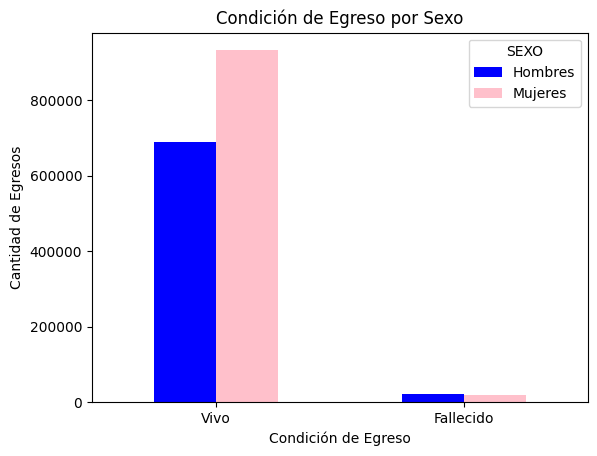

/tmp/ipython-input-3202348057.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Hombre' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  egresos_clean.loc[egresos_clean["SEXO"] == 1, "SEXO"] = "Hombre"
/tmp/ipython-input-3202348057.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Vivo' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  egresos_clean.loc[egresos_clean["CONDICION_EGRESO"] == 1, "CONDICION_EGRESO"] = "Vivo"


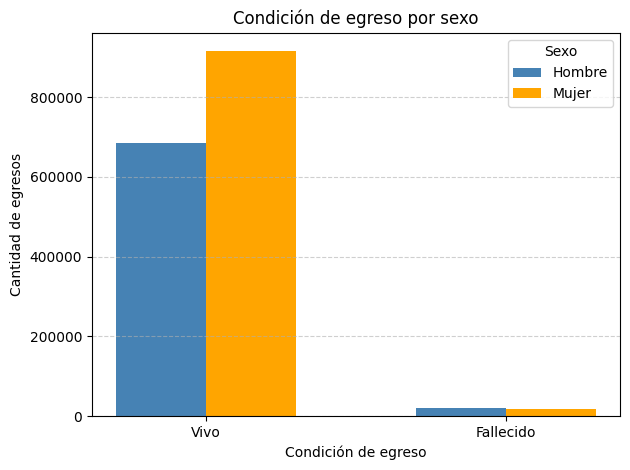

In [ ]:
# Reemplazar códigos por texto
egresos_clean.loc[egresos_clean["SEXO"] == 1, "SEXO"] = "Hombre"
egresos_clean.loc[egresos_clean["SEXO"] == 2, "SEXO"] = "Mujer"
egresos_clean.loc[egresos_clean["CONDICION_EGRESO"] == 1, "CONDICION_EGRESO"] = "Vivo"
egresos_clean.loc[egresos_clean["CONDICION_EGRESO"] == 2, "CONDICION_EGRESO"] = "Fallecido"

# Contar registros
tabla = egresos_clean.groupby(["CONDICION_EGRESO", "SEXO"]).size().reset_index(name="CANTIDAD")

# Extraer valores
hv = tabla[(tabla["CONDICION_EGRESO"]=="Vivo") & (tabla["SEXO"]=="Hombre")]["CANTIDAD"].sum()
hm = tabla[(tabla["CONDICION_EGRESO"]=="Fallecido") & (tabla["SEXO"]=="Hombre")]["CANTIDAD"].sum()
mv = tabla[(tabla["CONDICION_EGRESO"]=="Vivo") & (tabla["SEXO"]=="Mujer")]["CANTIDAD"].sum()
mm = tabla[(tabla["CONDICION_EGRESO"]=="Fallecido") & (tabla["SEXO"]=="Mujer")]["CANTIDAD"].sum()

# Posiciones simples
x = [0, 1]

# Graficar lado a lado
plt.bar([x[0]-0.15, x[1]-0.15], [hv, hm], width=0.3, color='steelblue', label='Hombre')
plt.bar([x[0]+0.15, x[1]+0.15], [mv, mm], width=0.3, color='orange', label='Mujer')

# Etiquetas
plt.xticks(x, ['Vivo', 'Fallecido'])
plt.xlabel('Condición de egreso')
plt.ylabel('Cantidad de egresos')
plt.title('Condición de egreso por sexo')
plt.legend(title='Sexo')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Ejercicio 7**

Ahora se busca evaluar la proporción de condición de egreso según el grupo etario. Para ello, genere un gráfico que muestre, para cada grupo etario, la distribución proporcional de las distintas condiciones de egreso. Responda:

* ¿Cúal es el grupo etario con mayor proporción de egresos fallecidos?
* ¿Cúal es el grupo etario con mayor proporción de egresos vivos?

Asegurese que el grafico muestre el orden correcto de los grupos etarios.

La imagen que debe lograr es la siguiente:

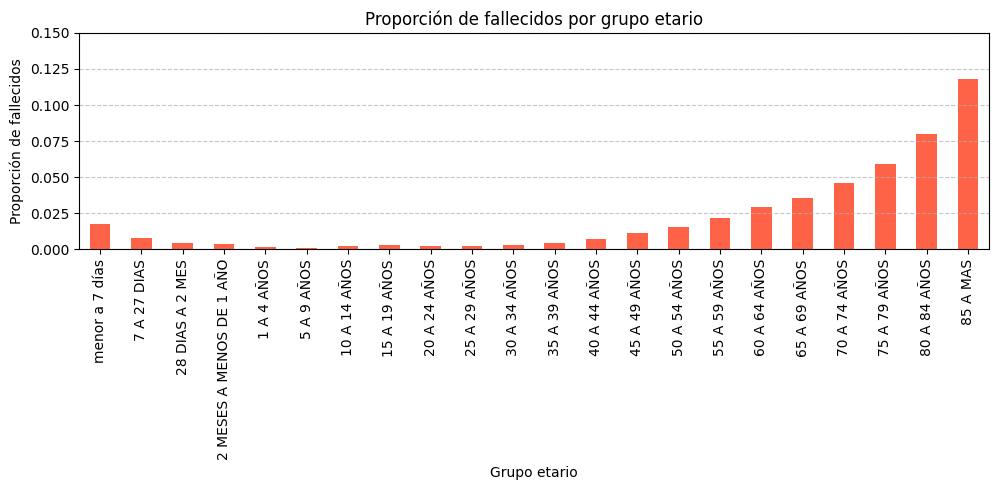


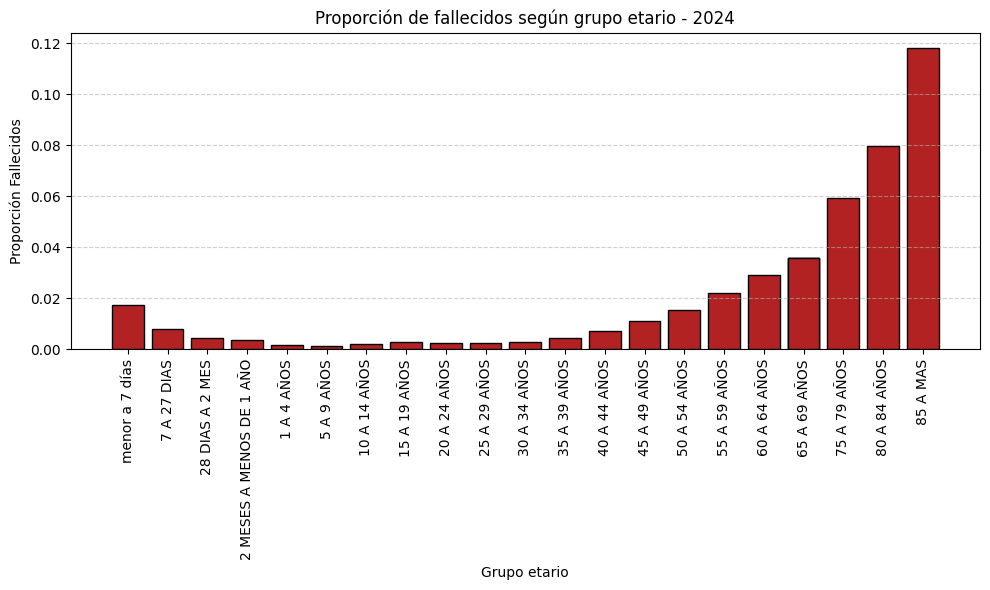

Mínimo: 0.0 % en 5 A 9 AÑOS
Máximo: 0.12 % en 85 A MAS


In [ ]:
egresos_clean["GRUPO_EDAD"].unique()
orden_edades = ['menor a 7 días', '7 A 27 DIAS', '28 DIAS A 2 MES',
                '2 MESES A MENOS DE 1 AÑO', '1 A 4 AÑOS', '5 A 9 AÑOS',
                '10 A 14 AÑOS', '15 A 19 AÑOS', '20 A 24 AÑOS', '25 A 29 AÑOS',
                '30 A 34 AÑOS',  '35 A 39 AÑOS', '40 A 44 AÑOS', '45 A 49 AÑOS',
                '50 A 54 AÑOS', '55 A 59 AÑOS',  '60 A 64 AÑOS', '65 A 69 AÑOS',
                '65 A 69 AÑOS', '65 A 69 AÑOS',  '75 A 79 AÑOS', '80 A 84 AÑOS',
                '85 A MAS']



# <CODE> Realizar el codigo que genere el grafico solicitado aquí.
tabla = pd.crosstab(
    egresos_clean["GRUPO_EDAD"],
    egresos_clean["CONDICION_EGRESO"],
   normalize="index"
    )

#Ordenar los grupos etarios
tabla = tabla.reindex(orden_edades, axis=0)


#GRAFICO
plt.figure(figsize=(10, 6))
plt.bar(
    tabla.index,
    tabla["Fallecido"],     # solo la columna de fallecidos
    color="firebrick",
    edgecolor="black"
)

plt.title("Proporción de fallecidos según grupo etario - 2024")
plt.xlabel("Grupo etario")
plt.ylabel("Proporción Fallecidos")
plt.xticks(rotation=90)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

valores = tabla["Fallecido"]
valor_minimo = valores.min()
valor_maximo = valores.max()

grupo_minimo = valores.idxmin()
grupo_maximo = valores.idxmax()

print("Mínimo:", round(valor_minimo, 2), "% en", grupo_minimo)
print("Máximo:", round(valor_maximo, 2), "% en", grupo_maximo)


**RESPONDER PREGUNTAS EJERCICIO 7 AQUÍ.**


*   ¿Cúal es el grupo etario con mayor proporción de egresos fallecidos?
    El grupo de 85 años o más.

*   ¿Cúal es el grupo etario con mayor proporción de egresos vivos?
    El grupo de 5 a 9 años.

#### **Ejercicio 8**

De igual manera realize un gráfico que muestre la proporción de condición de egreso según la previsión de salud. Responda:
* ¿Cúal es la previsión de salud con mayor proporción de egresos fallecidos?
* ¿Cúal es la previsión de salud con mayor proporción de egresos vivos?


La imagen que debe lograr es la siguiente:

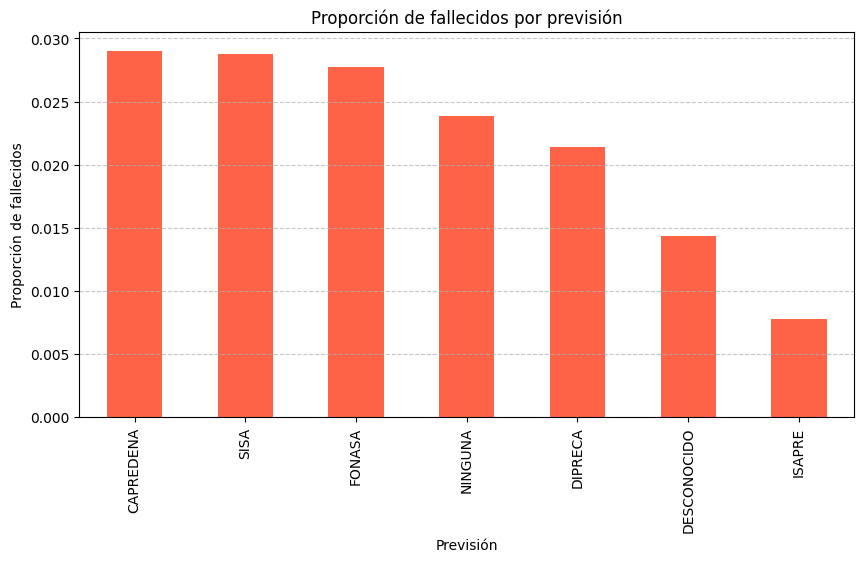

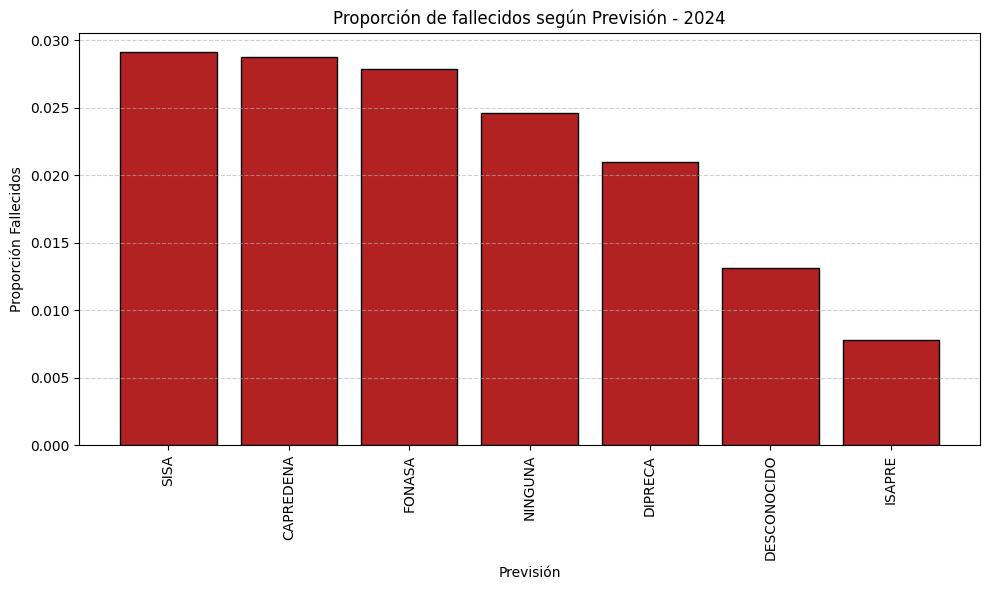

CONDICION_EGRESO  Fallecido      Vivo
GLOSA_PREVISION                      
SISA               0.029103  0.970897
CAPREDENA          0.028749  0.971251
FONASA             0.027875  0.972125
NINGUNA            0.024607  0.975393
DIPRECA            0.020968  0.979032
DESCONOCIDO        0.013132  0.986868
ISAPRE             0.007828  0.992172


In [ ]:
# <CODE> Realizar el codigo que genere el grafico solicitado aquí.


tabla = pd.crosstab(
    egresos_clean["GLOSA_PREVISION"],
    egresos_clean["CONDICION_EGRESO"], normalize="index"
    )
tabla = tabla.sort_values(by="Fallecido", ascending=False)

#GRAFICO
plt.figure(figsize=(10, 6))
plt.bar(
    tabla.index,
    tabla["Fallecido"],     # solo la columna de fallecidos
    color="firebrick",
    edgecolor="black")

plt.title("Proporción de fallecidos según Previsión - 2024")
plt.xlabel("Previsión")
plt.ylabel("Proporción Fallecidos")
plt.xticks(rotation=90)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print(tabla)


**RESPONDER PREGUNTAS EJERCICIO 8 AQUÍ.**

*   ¿Cúal es la previsión de salud con mayor proporción de egresos fallecidos?
    La previsión con mayor proporcion de egresos fallecidos es SISA


*   ¿Cúal es la previsión de salud con mayor proporción de egresos vivos?
    La previsión con mayor proporcion de egresos vivos es ISAPRE



#### **Ejercicio 9**

Ahora se busca evaluar la cantidad de días segun la región de residencia.  Para ello, genere un gráfico que muestre, para cada región, la cantidad de días promedio de estadía en el hospital. Responda:
* ¿Cúal es la región con mayor cantidad de días promedio de estadía?
* ¿Cúal es la región con menor cantidad de días promedio de estadía?
* ¿Cúal es la región con mayor cantidad de egresos?
* ¿Cúal es la región con menor cantidad de egresos?
* ¿Existen datos nulos?


La imagen que debe lograr es la siguiente:
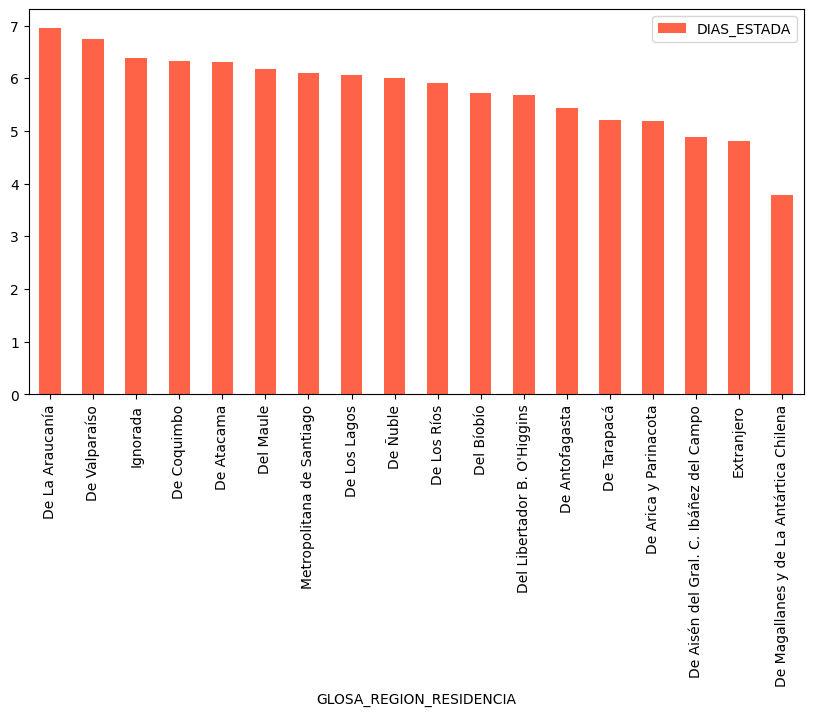


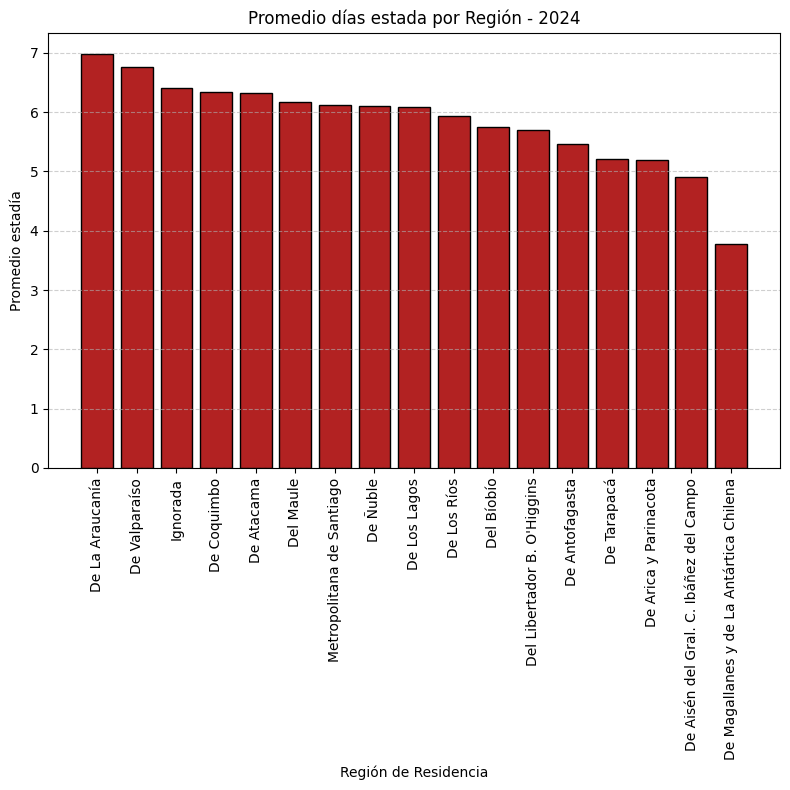

In [ ]:
# <CODE> Realizar el codigo que genere el grafico solicitado aquí.

# Calcular promedio días de estadía por región
promedio_dias_estada_por_region = egresos_clean.groupby('GLOSA_REGION_RESIDENCIA')['DIAS_ESTADA'].mean()

# ordenar barras por numero descendente
promedio_dias_estada_por_region = promedio_dias_estada_por_region.sort_values(ascending=False)


#GRAFICO
plt.figure(figsize=(8, 8))
plt.bar(
    promedio_dias_estada_por_region.index,
    promedio_dias_estada_por_region.values,     # ajustar altura
    color="firebrick",
    edgecolor="black")

plt.title("Promedio días estada por Región - 2024")
plt.xlabel("Región de Residencia")
plt.ylabel("Promedio estadía")
plt.xticks(rotation=90)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**RESPONDER PREGUNTAS EJERCICIO 9 AQUÍ.**



*   ¿Cúal es la región con mayor cantidad de días promedio de estadía? Region de la Araucania.

*   ¿Cúal es la región con menor cantidad de días promedio de estadía? Region de Magallanes y de la Antartida Chilena.

*   ¿Cúal es la región con mayor cantidad de egresos? La region Metropolitana con 648390 egresos.

*   ¿Cúal es la región con menor cantidad de egresos?
La de Magallanes y Antartida Chilena con 8807 egresos.

*   ¿Existen datos nulos?
No hay datos nulos ya que fueron limpiados anteriormente, sin embargo se considera una columna con región de residencia ignorada.

In [ ]:
# Contar egresos por región
egresos_por_region = egresos_clean.groupby('GLOSA_REGION_RESIDENCIA').size()

# Mostrar la región con mayor cantidad de egresos
region_max = egresos_por_region.idxmax()
cantidad_max = egresos_por_region.max()

print(f"La región con más egresos es {region_max}, con {cantidad_max} egresos.")

# Mostrar la región con menor cantidad de egresos
region_min = egresos_por_region.idxmin()
cantidad_min = egresos_por_region.min()

print(f"La región con menos egresos es {region_min}, con {cantidad_min} egresos.")

La región con más egresos es Metropolitana de Santiago, con 648390 egresos.
La región con menos egresos es De Magallanes y de La Antártica Chilena, con 8807 egresos.


In [ ]:
#datos nulos?
egresos_clean.isnull().sum()
#No hay datos nulos

,0
PERTENENCIA_ESTABLECIMIENTO_SALUD,0
SEXO,0
GRUPO_EDAD,0
GLOSA_PAIS_ORIGEN,0
COMUNA_RESIDENCIA,0
GLOSA_COMUNA_RESIDENCIA,0
REGION_RESIDENCIA,0
GLOSA_REGION_RESIDENCIA,0
PREVISION,0
GLOSA_PREVISION,0


#### **Ejercicio 10**

Utilizando el diagnostico principal (DIAG1), calcule los 10 diagnósticos más frecuentes para egresos de tipo 1 y extraiga los nombres desde el archivo `Diccionario BD egresos hospitalario.xlsx`, que se leyo al principio de este taller.
* ¿Cúal es el diagnóstico más frecuente?
* ¿Cúal es el diagnóstico menos frecuente?

In [ ]:
# <CODE> Código que responda cual es el diagnóstico mas frecuente?
egresos_clean_TIPO1 = egresos_clean[egresos_clean["CONDICION_EGRESO"] == 'Vivo']

# Calcula 10 diagnosticos más frecuentes para egreso tipo 1(Vivo)
top_10_diag1_tipo1 = egresos_clean_TIPO1['DIAG1'].value_counts().head(10)

# Traer traduccion del diccionario
diag1_con_traduccion = df_codigos_clean.set_index('CODIGO SUBCATEGORIA')['GLOSA SUBCATEGORIA'].to_dict()

# Une traduccion y top10
top_10_diag1_tipo1_traducido = top_10_diag1_tipo1.rename(index=diag1_con_traduccion)

print("Top 10 diagnósticos más frecuentes para egresos tipo 1 (Vivo):")
display(top_10_diag1_tipo1_traducido)

Top 10 diagnósticos más frecuentes para egresos tipo 1 (Vivo):


,count
DIAG1,
"PARTO UNICO ESPONTANEO, PRESENTACION CEFALICA DE VERTICE",22488
OTRAS APENDICITIS AGUDAS Y LAS NO ESPECIFICADAS,21271
CALCULO DE LA VESICULA BILIAR SIN COLECISTITIS,20117
PARTO POR CESAREA ELECTIVA,18764
"PARTO POR CESAREA, SIN OTRA ESPECIFICACION",18088
"NEUMONIA, NO ESPECIFICADA",16491
"INFECCION DE VÍAS URINARIAS, SITIO NO ESPECIFICADO",14994
OTRAS COLELITIASIS,14597
"PARTO UNICO ESPONTANEO, SIN OTRA ESPECIFICACION",14281


In [ ]:
# <CODE> Código que responda cual es el diagnóstico menos frecuente?

menosfrec_diag1_tipo1 = egresos_clean_TIPO1['DIAG1'].value_counts().tail()

# traduce del diccionario
diag1_con_traduccion = df_codigos_clean.set_index('CODIGO SUBCATEGORIA')['GLOSA SUBCATEGORIA'].to_dict()

# junta dx con traduccion
menosfrec_diag1_tipo1_con_traduccion = menosfrec_diag1_tipo1.rename(index=diag1_con_traduccion)

# Contar los diagnósticos
conteo_diag1 = egresos_clean_TIPO1["DIAG1"].value_counts()

# Filtrar los que tienen frecuencia 1
diagnosticos_unicos = conteo_diag1[conteo_diag1 == 1]

# Mostrar cantidad total
print("Cantidad de diagnósticos únicos (solo 1 caso):", len(diagnosticos_unicos))
print("Algunos ejemplos para egresos tipo 1 (Vivo):", menosfrec_diag1_tipo1_con_traduccion)

Cantidad de diagnósticos únicos (solo 1 caso): 617
Algunos ejemplos para egresos tipo 1 (Vivo): DIAG1
HALLAZGO CROMOSOMICO O GENETICO ANORMAL EN EL EXAMEN PRENATAL DE LA MADRE        1
SÍNDROME POSTENCEFALITICO                                                        1
CONEXION ANOMALA DE LA VENA PORTA                                                1
TRISOMIA DE UN CROMOSOMA COMPLETO, MOSAICO (POR FALTA DE DISYUNCION MITOTICA)    1
INFECCIÓN DEBIDA A CHLAMYDIA PSITTACI                                            1
Name: count, dtype: int64


**RESPONDER PREGUNTAS EJERCICIO 10 AQUÍ.**

* ¿Cúal es el diagnóstico más frecuente?
El diagnóstico más frecuente para egresos tipo 1 (Vivo) es PARTO UNICO ESPONTANEO, PRESENTACION CEFALICA DE VERTICE.
* ¿Cúal es el diagnóstico menos frecuente?
El diagnóstico menos frecuente para egresos tipo 1 (Vivo) son 617 que tienen solo 1 diagnistico de egreso, entre ellos infección debida a chlamydia psittaci y trisomia de un cromosoma completo, mosaico

**RESPONDER PREGUNTAS EJERCICIO 10 AQUÍ.**

#### **Ejercicio 11**

Utilizando el diagnostico principal (DIAG1), calcule los 10 diagnósticos más frecuentes para egresos de tipo 2 y extraida los nombres desde el archivo `Diccionario BD egresos hospitalario.xlsx`, que se leyo al principio de este taller.
* ¿Cúal es el diagnóstico más frecuente?
* ¿Cúal es el diagnóstico menos frecuente?


In [ ]:
# <CODE> Código que responda cual es el diagnóstico mas frecuente?
egresos_clean_TIPO2 = egresos_clean[egresos_clean["CONDICION_EGRESO"] == 'Fallecido']

# Calcula 10 diagnosticos más frecuentes para egreso tipo 2(Fallecido)
top_10_diag1_tipo2 = egresos_clean_TIPO2['DIAG1'].value_counts().head(10)

# Traer traduccion del diccionario
diag1_con_traduccion = df_codigos_clean.set_index('CODIGO SUBCATEGORIA')['GLOSA SUBCATEGORIA'].to_dict()

# Une traduccion y top10
top_10_diag1_tipo2_traducido = top_10_diag1_tipo2.rename(index=diag1_con_traduccion)

print("Top 10 diagnósticos más frecuentes para egresos tipo 2 (Fallecido):")
display(top_10_diag1_tipo2_traducido)

Top 10 diagnósticos más frecuentes para egresos tipo 2 (Fallecido):


,count
DIAG1,
INSUFICIENCIA RESPIRATORIA AGUDA,3131
"NEUMONIA, NO ESPECIFICADA",1998
"SEPTICEMIA, NO ESPECIFICADA",1954
"NEUMONIA BACTERIANA, NO ESPECIFICADA",990
NEUMONITIS DEBIDA A ASPIRACION DE ALIMENTO O VOMITO,963
OTRAS SEPTICEMIAS ESPECIFICADAS,683
INSUFICIENCIA CARDIACA CONGESTIVA,659
"INSUFICIENCIA RESPIRATORIA, NO ESPECIFICADA",648
"INFECCION DE VÍAS URINARIAS, SITIO NO ESPECIFICADO",555


In [ ]:
# <CODE> Código que responda cual es el diagnóstico menos frecuente?
menosfrec_diag1_tipo2 = egresos_clean_TIPO2['DIAG1'].value_counts().tail()

# traduce del diccionario
diag1_con_traduccion = df_codigos_clean.set_index('CODIGO SUBCATEGORIA')['GLOSA SUBCATEGORIA'].to_dict()

# junta dx con traduccion
menosfrec_diag1_tipo2_con_traduccion = menosfrec_diag1_tipo2.rename(index=diag1_con_traduccion)

# Contar los diagnósticos
conteo_diag1 = egresos_clean_TIPO2["DIAG1"].value_counts()

# Filtrar los que tienen frecuencia 1
diagnosticos_unicos = conteo_diag1[conteo_diag1 == 1]

# Mostrar cantidad total
print("Cantidad de diagnósticos únicos (solo 1 caso):", len(diagnosticos_unicos))



print("Algunos ejemplos para egresos tipo 2 (Fallecido):", menosfrec_diag1_tipo2_con_traduccion )

Cantidad de diagnósticos únicos (solo 1 caso): 744
Algunos ejemplos para egresos tipo 2 (Fallecido): DIAG1
ESTENOSIS HIPERTROFICA CONGENITA DEL PILORO                                    1
TRASTORNO MENTAL ORGÁNICO O SINTOMÁTICO, NO ESPECIFICADO                       1
FISTULA DEL ESTOMAGO Y DEL DUODENO                                             1
TRAUMATISMO DE MULTIPLES VASOS SANGUINEOS A NIVEL DE LA MUÑECA Y DE LA MANO    1
EFECTOS DE LA CORRIENTE ELECTRICA                                              1
Name: count, dtype: int64


**RESPONDER PREGUNTAS EJERCICIO 11 AQUÍ.**



*   ¿Cúal es el diagnóstico más frecuente?
       El diagnostico con mayor frecuencia es INSUFICIENCIA RESPIRATORIA AGUDA.

*   ¿Cúal es el diagnóstico menos frecuente?
       Son 744 diagnosticos con solo un caso de egreso Fallecido, entre ellos efectos de la corriente electrica.

